In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import calendar

# Domain & Period

In [11]:
iyear=1981
fyear=2024
dom='HK+'
latS,latN,lonW,lonE = coord_domain(dom)

# Elevation data

In [3]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_chirps_hma_grid.nc')['elevation']
elev = field_dom(elev,dom)

# Seasonal Mean data

In [4]:
tp = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1981-2025_CHIRPS.nc')['tp']
tp = field_dom(tp, dom)
tp = tp.sel(time=slice(str(iyear),str(fyear)))

In [5]:
seasons = ["DJFM","AM","JJAS","ON"]

tp_dict = {}

for season in seasons:
    tp_season = clim(tp, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
    tp_dict[season] = tp_season

150


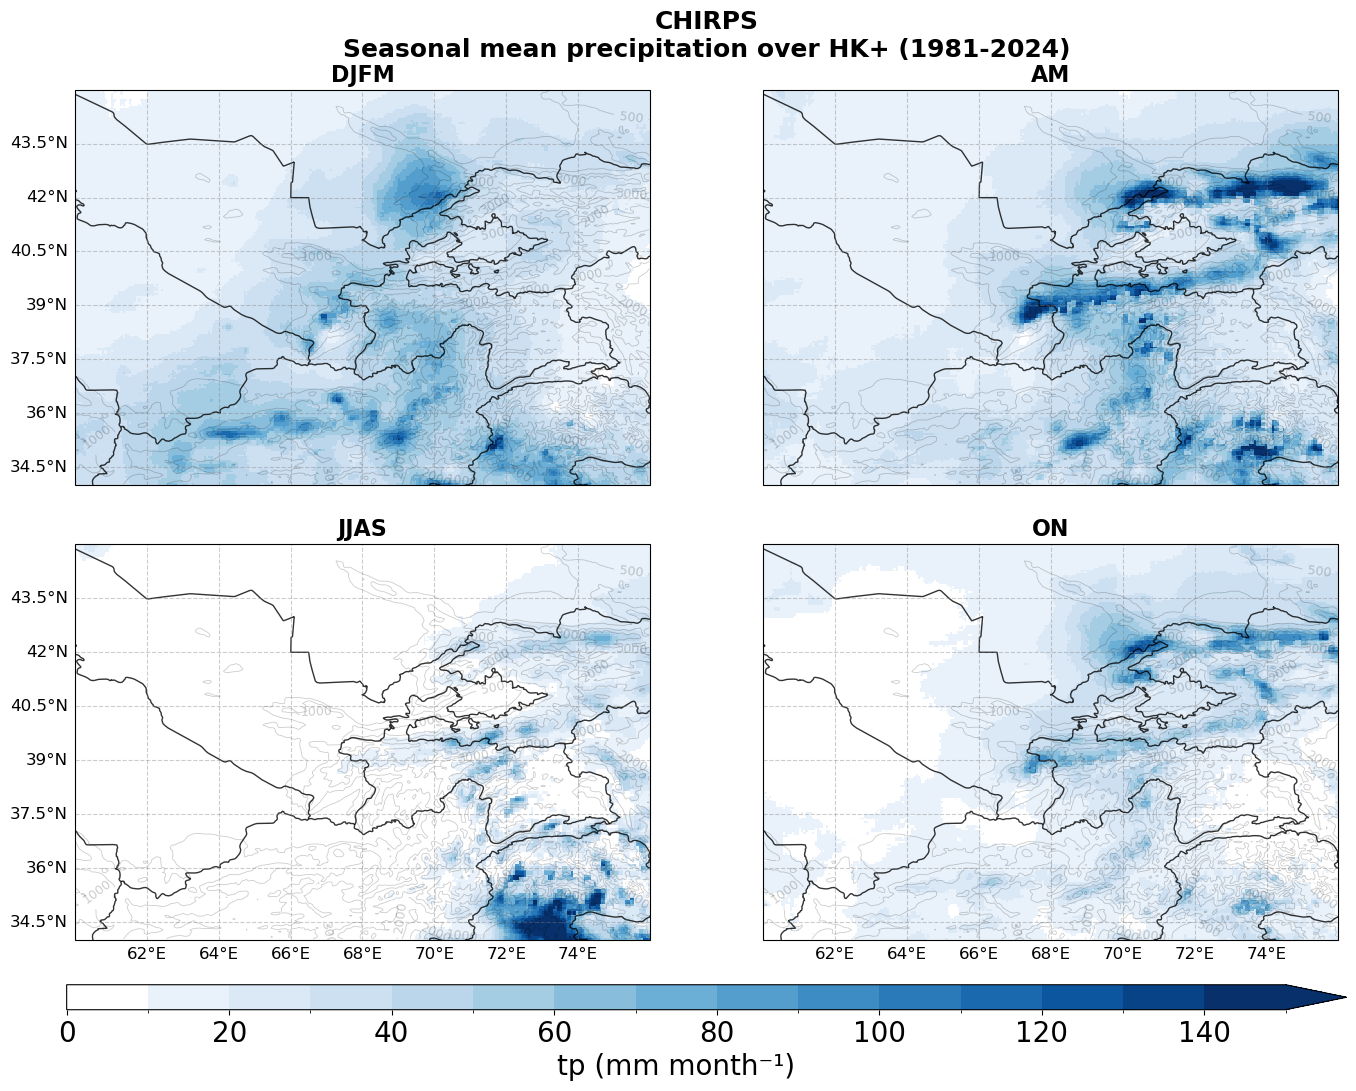

In [7]:
#==================== Color grading ============================

step = 10
vmax = 150
print(vmax)
levels = np.arange(0, vmax + step, step)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = tp_dict[season]
       
    im = ax.pcolormesh(
           data_model['lon'], data_model['lat'], data_model,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto"
       )
        
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        elev.longitude,
        elev.latitude,
        elev,
        levels=[500,1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.6,
        alpha=0.2,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, -0.02, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.9, bottom=0.05, wspace=0.05, hspace=0.15)
plt.suptitle(
    f"CHIRPS\nSeasonal mean precipitation over HK+ ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()

150


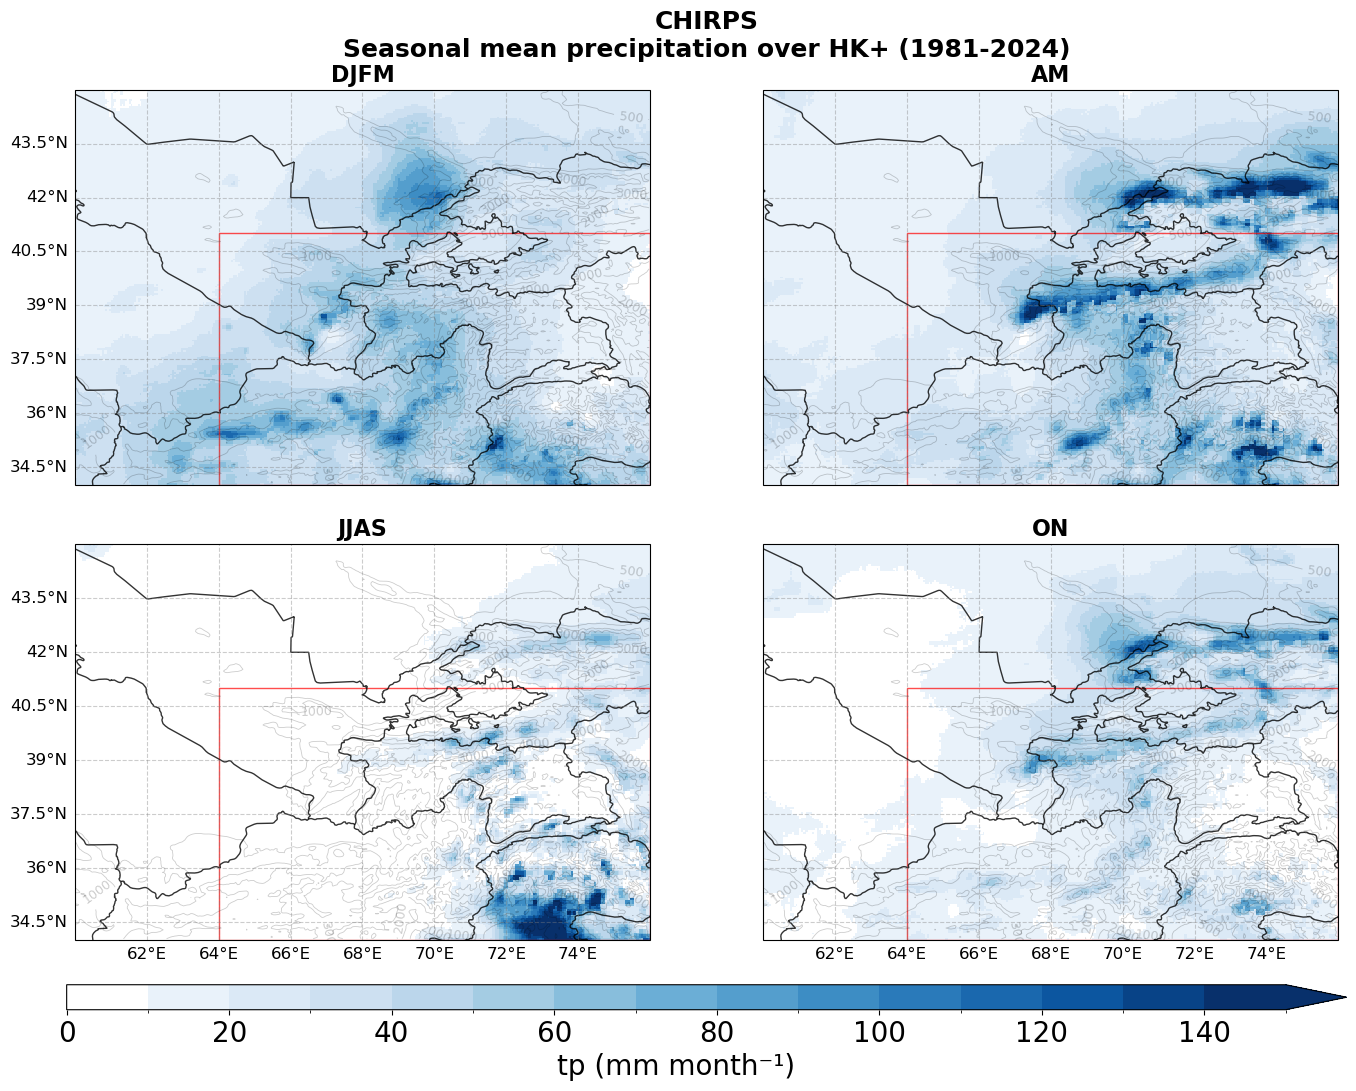

In [12]:
#==================== Color grading ============================

step = 10
vmax = 150
print(vmax)
levels = np.arange(0, vmax + step, step)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = tp_dict[season]
       
    im = ax.pcolormesh(
           data_model['lon'], data_model['lat'], data_model,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto"
       )
        
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        elev.longitude,
        elev.latitude,
        elev,
        levels=[500,1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.6,
        alpha=0.2,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

    #HK zone
    latS2, latN2, lonW2, lonE2 = coord_domain('HK')
    rect = mpatches.Rectangle((lonW2, latS2), lonE2 - lonW2, latN2 - latS2,linewidth=1, edgecolor='red', facecolor='none',
                              alpha=0.7, transform=ccrs.PlateCarree())
    ax.add_patch(rect)

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, -0.02, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.9, bottom=0.05, wspace=0.05, hspace=0.15)
plt.suptitle(
    f"CHIRPS\nSeasonal mean precipitation over HK+ ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()

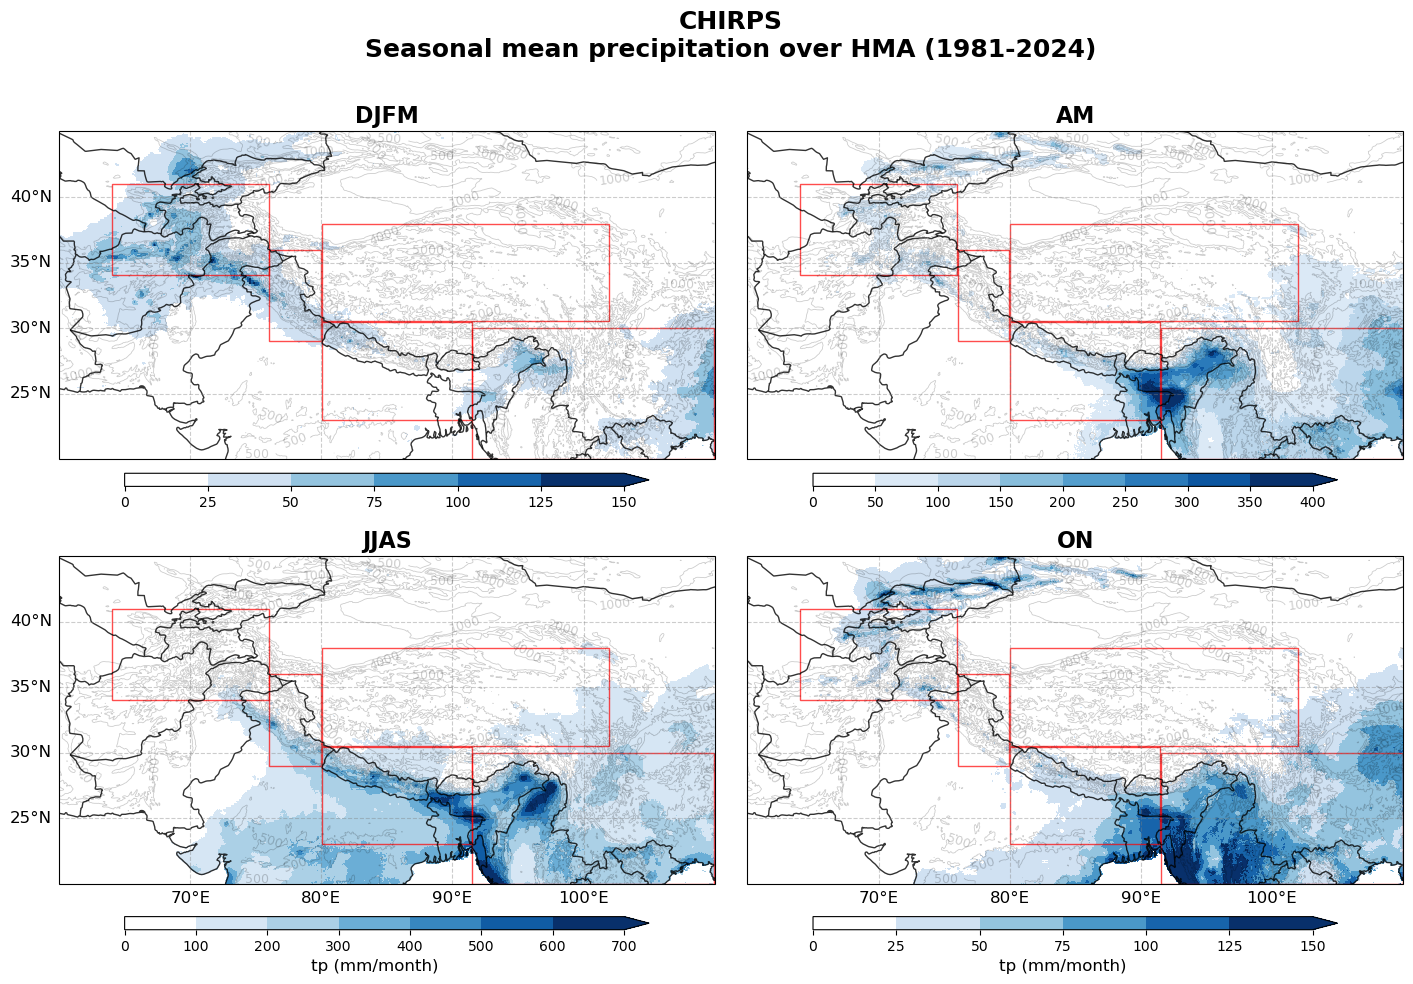

In [21]:
# to have a colorbar for each season

vmax_dict = {
    "DJFM": 150,
    "AM": 400,
    "JJAS": 700,
    "ON": 150
}

step_dict = {
    "DJFM": 25,
    "AM": 50,
    "JJAS": 100,
    "ON": 25
}

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = tp_dict[season]

    # color grading
    vmax = vmax_dict[season]
    step = step_dict[season]
    levels = np.arange(0, vmax + step, step)
    base_cmap = plt.get_cmap("Blues", len(levels)-1)
    colors = base_cmap(np.arange(base_cmap.N))
    colors[0] = [1, 1, 1, 1]
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))
    
    im = ax.pcolormesh(
           data_model['lon'], data_model['lat'], data_model,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto"
       )

    #Colorbar for each season
    if i in [2,3]:
        cbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.07, shrink=0.8, fraction=0.05, aspect=40, extend='max')
        cbar.set_label("tp (mm/month)", fontsize=12)
    else:
        cbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.03, shrink=0.8, fraction=0.05, aspect=40, extend='max')
    cbar.ax.tick_params(labelsize=10)
    
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        elev.longitude,
        elev.latitude,
        elev,
        levels=[500,1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.6,
        alpha=0.2,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

    # Add red rectangles for subdomains
    for box in [CH_box, HK_box, TP_box, SEH_box, SL_box]:
        rect = Rectangle((box[0], box[2]), box[1]-box[0], box[3]-box[2],
                         linewidth=1, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree(), alpha=0.7)
        ax.add_patch(rect)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.96, bottom=0.05, wspace=0.05, hspace=-0.05)
plt.suptitle(
    f"CHIRPS\nSeasonal mean precipitation over HMA ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()

# Seasonal Trends data

In [9]:
seasons = {"DJFM": [12,1,2,3], 
           "AM": [4,5], 
           "JJAS": [6,7,8,9], 
           "ON": [10,11]}

trend_dict = {}
p_dict={}

for season in seasons:
    tp_season = seasonal_selection2(tp, seasons[season], iyear, fyear)
    par = trend_vect(tp_season.time, tp_season, dim='time')
    trend=par[0]*10; p=par[3]
    trend_dict[season]=trend
    p_dict[season]=p

25


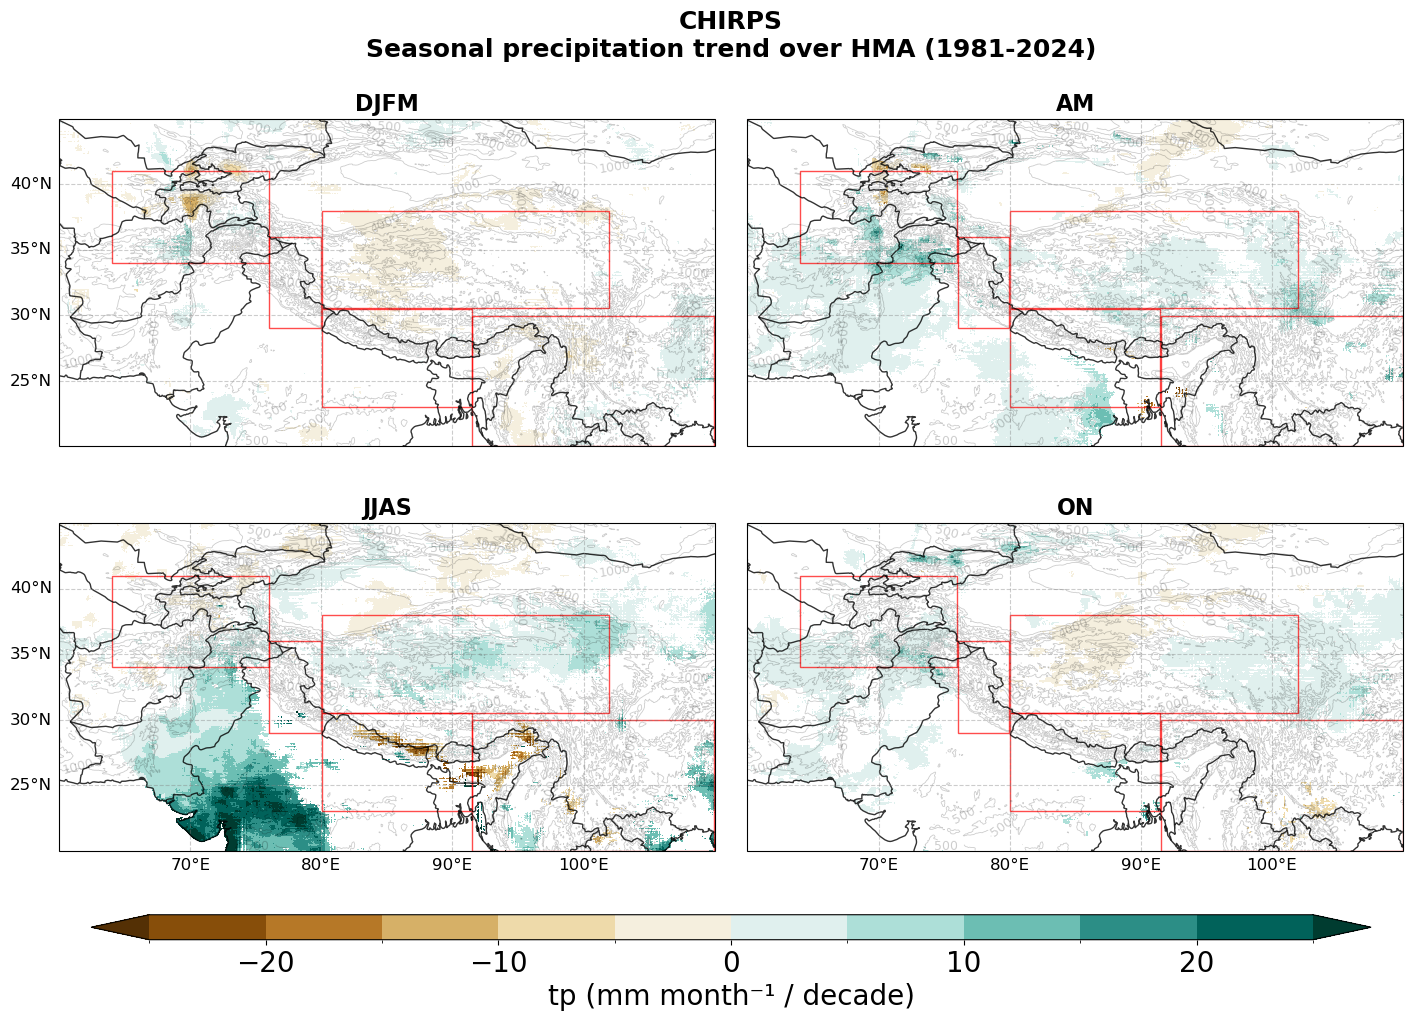

In [10]:
seasons = ['DJFM','AM','JJAS','ON']

#==================== Color grading ============================

step = 5
vmax = 25
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
cmap = cmap.copy()         # permet de modifier
cmap.set_bad(color='white')  # les NaN apparaissent en blanc
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = trend_dict[season]

    # Masque blanc pour zones non significatives
    sig = p_dict[season] < 0.05  # True = significatif
    
    # Crée une copie pour le plot avec NaN pour non significatif
    data_plot = data_model.where(sig)
    
    im = ax.pcolormesh(
           data_model['lon'], data_model['lat'], data_plot,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto"
       )
    
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        elev.longitude,
        elev.latitude,
        elev,
        levels=[500,1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.6,
        alpha=0.2,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

    # Add red rectangles for subdomains
    for box in [CH_box, HK_box, TP_box, SEH_box, SL_box]:
        rect = Rectangle((box[0], box[2]), box[1]-box[0], box[3]-box[2],
                         linewidth=1, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree(), alpha=0.7)
        ax.add_patch(rect)

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, 0.05, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp (mm month⁻¹ / decade)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.96, bottom=0.05, wspace=0.05, hspace=-0.2)
plt.suptitle(
    f"CHIRPS\nSeasonal precipitation trend over HMA ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()

# Percentage trends

In [11]:
seasons = ["DJFM","AM","JJAS","ON"]

trend_percentage_dict = {}

for season in seasons:
    mean = tp_dict[season]
    trend = trend_dict[season]
    
    trend_percentage_dict[season] = (trend_dict[season] / tp_dict[season]).where(tp_dict[season] != 0) * 100

30


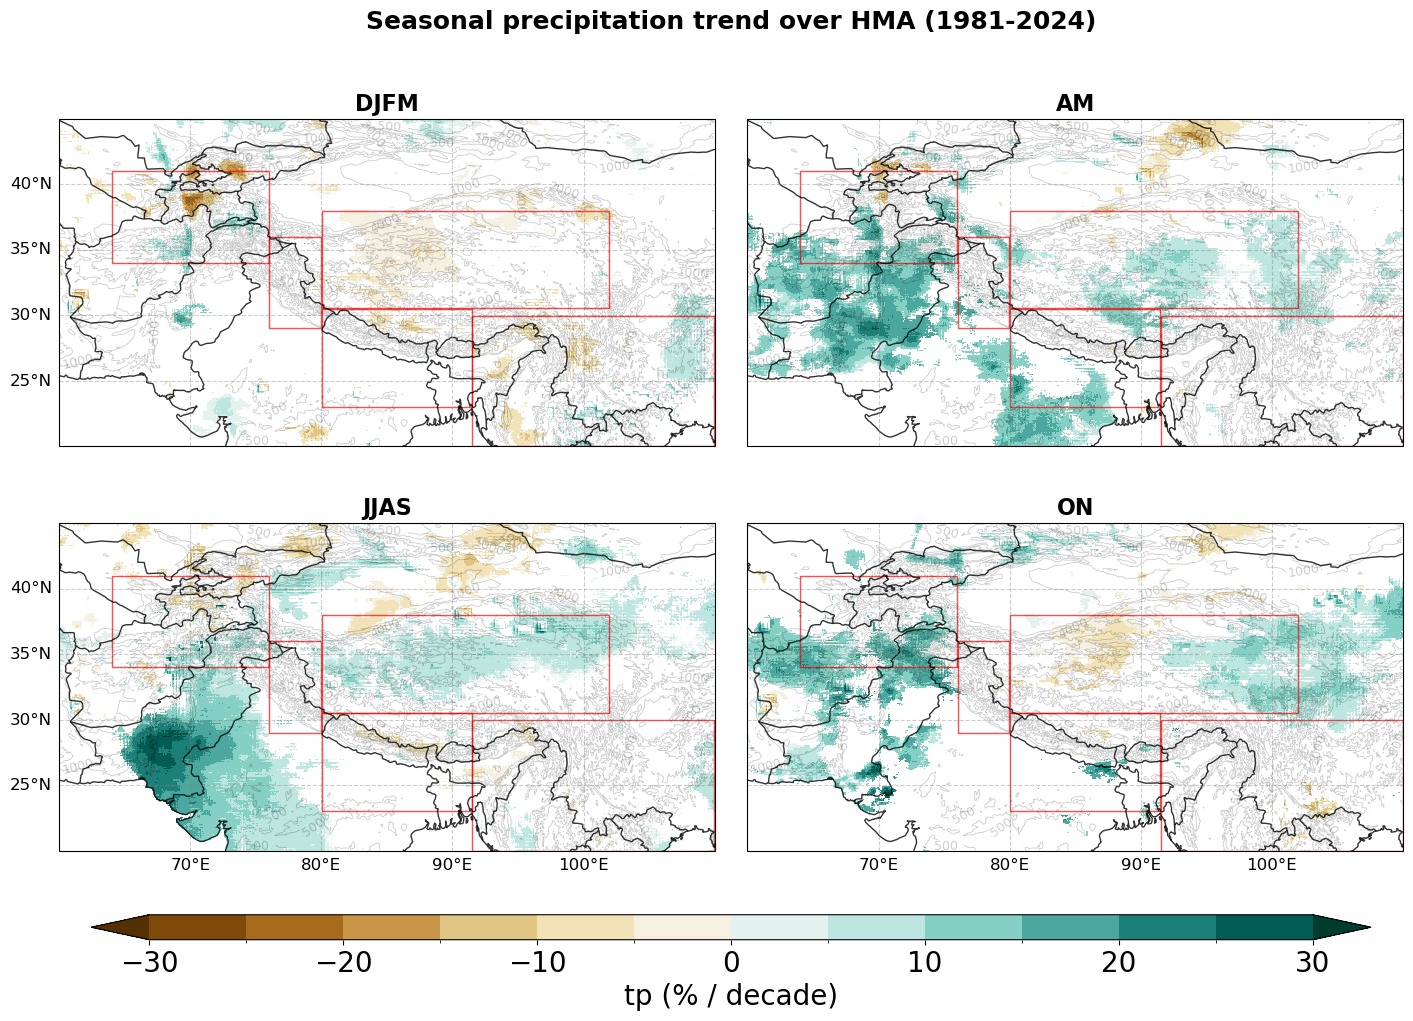

In [12]:
seasons = ['DJFM','AM','JJAS','ON']

#==================== Color grading ============================

step = 5
vmax = 30
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
cmap = cmap.copy()         # permet de modifier
cmap.set_bad(color='white')  # les NaN apparaissent en blanc
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = trend_percentage_dict[season]

    # Masque blanc pour zones non significatives
    sig = p_dict[season] < 0.05  # True = significatif
    
    # Crée une copie pour le plot avec NaN pour non significatif
    data_plot = data_model.where(sig)
    
    im = ax.pcolormesh(
           data_model['lon'], data_model['lat'], data_plot,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto"
       )
    
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        elev.longitude,
        elev.latitude,
        elev,
        levels=[500,1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.6,
        alpha=0.2,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

    # Add red rectangles for subdomains
    for box in [CH_box, HK_box, TP_box, SEH_box, SL_box]:
        rect = Rectangle((box[0], box[2]), box[1]-box[0], box[3]-box[2],
                         linewidth=1, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree(), alpha=0.7)
        ax.add_patch(rect)

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, 0.05, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp (% / decade)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.96, bottom=0.05, wspace=0.05, hspace=-0.2)
plt.suptitle(
    f"Seasonal precipitation trend over HMA ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()